# Случайный лес

В этом практическом задании вы решите задачу регрессии на реальных данных при помощи линейной модели и случайного леса. 

## Цели практической работы

* Научиться применять случайный лес в задаче регрессии.
* Научиться сравнивать качество случайного леса с качеством линейной модели.
* Научиться настраивать гиперпараметры леса.

## Что входит в работу

* Выполнить предобработку данных.
* Обучить линейную регрессию на данных задачи.
* Обучить случайный лес на данных задачи.
* Подобрать гиперпараметры для леса.
* Визуализировать важность признаков у леса.

## Что оценивается

*  Все ячейки заполнены; при запуске ячеек  Python не выдаёт информацию об ошибках.
*  Качество итоговой модели $R^2$ превышает 0,95.


## Что нужно сделать

Постройте модели, предсказывающие стоимость автомобилей по характеристикам.

Признаков у машин много, но в этой работе обойдёмся только числовыми признаками:
*  year — год производства автомобиля;
*  km_driven — пробег;
*  seats — количество посадочных мест;
*  mileage — другая характеристика пробега;
*  engine — мощность двигателя;
*  max_power — мощность автомобиля.

Целевая переменная — selling_price.

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("cars_train.csv")
test = pd.read_csv("cars_test.csv")
train

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014.0,450000.0,145500.0,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014.0,370000.0,120000.0,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Hyundai i20 Sportz Diesel,2010.0,225000.0,127000.0,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
3,"Maruti Swift VXI BSIII,2007,130000,120000,Petr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hyundai Xcent 1.2 VTVT E Plus,2017.0,440000.0,45000.0,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6993,Hyundai i20 Magna,2013.0,320000.0,110000.0,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
6994,"Hyundai Verna CRDi SX,2007,135000,119000,Diese...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6995,Maruti Swift Dzire ZDi,2009.0,382000.0,120000.0,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
6996,Tata Indigo CR4,2013.0,290000.0,25000.0,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [2]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import r2_score


Создайте объекты Xtrain, ytrain, Xtest, ytest. Запишите в них матрицы «объект — признак» и векторы целевой переменной для тренировочного и тестового датасетов.

In [3]:
# Ваш код здесь

В тренировочных данных есть автомобили, для которых неизвестна стоимость. Удалите эти автомобили из трейна.

In [4]:
# Ваш код здесь

In [5]:
#Удаляем автомобили из трейна, для которых неизвестна стоимость. 
train_nan = train[train.selling_price.isna()]
train = train[~train.index.isin(train_nan.index)] 

#отбросим единицы измерения и оставим только числа
train['mileage'] = train.mileage.str.split(' ').str[0].astype(float) 
train['max_power'] = train.max_power.str.split(' ').str[0].astype(float) 
train['engine'] = train.engine.str.split(' ').str[0] #тип сразу не задаем, чтобы не обрабатывать NaN
train.engine = train.engine.astype(float)

test['mileage'] = test.mileage.str.split(' ').str[0].astype(float) 
test['max_power'] = test.max_power.str.split(' ').str[0].astype(float) 
test['engine'] = test.engine.str.split(' ').str[0] #тип сразу не задаем, чтобы не обрабатывать NaN
test.engine = test.engine.astype(float)

#Создаем объекты Xtrain, ytrain, Xtest, ytest.
y_train = train['selling_price']
X_train = train.drop(['selling_price'], axis=1)

y_test = test['selling_price']
X_test = test.drop(['selling_price'], axis=1)


Перед обучением моделей обработайте данные.

Обратите внимание, что столбцы mileage, engine и max_power по смыслу числовые. Чтобы превратить их в числовые столбцы, отбросьте единицы измерения и оставьте только числа. В столбцах есть пропущенные значения, их при обработке трогать не нужно.

In [6]:
# Ваш код здесь
train

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014.0,450000.0,145500.0,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014.0,370000.0,120000.0,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Hyundai i20 Sportz Diesel,2010.0,225000.0,127000.0,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017.0,440000.0,45000.0,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,113.75nm@ 4000rpm,5.0
6,Maruti 800 DX BSII,2001.0,45000.0,5000.0,Petrol,Individual,Manual,Second Owner,16.10,796.0,37.00,59Nm@ 2500rpm,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6992,Maruti Wagon R VXI BS IV with ABS,2013.0,260000.0,50000.0,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.10,90Nm@ 3500rpm,5.0
6993,Hyundai i20 Magna,2013.0,320000.0,110000.0,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0
6995,Maruti Swift Dzire ZDi,2009.0,382000.0,120000.0,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.90,190Nm@ 2000rpm,5.0
6996,Tata Indigo CR4,2013.0,290000.0,25000.0,Diesel,Individual,Manual,First Owner,23.57,1396.0,70.00,140Nm@ 1800-3000rpm,5.0


Оставьте в данных только шесть числовых столбцов:

year, km_driven, seats, engine, mileage, max_power

In [7]:
# Ваш код здесь
X_train = X_train[['year', 'km_driven', 'seats', 'engine', 'mileage', 'max_power']]
X_test = X_test[['year', 'km_driven', 'seats', 'engine', 'mileage', 'max_power']]
X_train

,year,km_driven,seats,engine,mileage,max_power
0,2014.0,145500.0,5.0,1248.0,23.40,74.00
1,2014.0,120000.0,5.0,1498.0,21.14,103.52
2,2010.0,127000.0,5.0,1396.0,23.00,90.00
4,2017.0,45000.0,5.0,1197.0,20.14,81.86
6,2001.0,5000.0,4.0,796.0,16.10,37.00
...,...,...,...,...,...,...
6992,2013.0,50000.0,5.0,998.0,18.90,67.10
6993,2013.0,110000.0,5.0,1197.0,18.50,82.85
6995,2009.0,120000.0,5.0,1248.0,19.30,73.90
6996,2013.0,25000.0,5.0,1396.0,23.57,70.00


Теперь заполните пропуски следующим образом:

*    вычислите средние значения по столбцам тренировочной выборки;

*    добавьте в пропуски в тренировочных и тестовых данных вычисленные средние.

In [8]:
# Ваш код здесь
for elem in X_train.columns:
    X_train[elem] = X_train[elem].fillna(float(X_train[elem].mean()))
    X_test[elem] = X_test[elem].fillna(float(X_test[elem].mean()))

Теперь на обработанных тренировочных данных обучите:

*  линейную регрессию,
*  случайный лес с параметрами по умолчанию.

На обработанных тестовых данных сделайте предсказание и вычислите метрику $R^2$. 

In [9]:
# Ваш код здесь
model_logreg = LogisticRegression()
model_logreg.fit(X_train, y_train)
y_pred_lr = model_logreg.predict(X_test)
r2_score(y_test, y_pred_lr)

0.044702137608272685

In [10]:
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
r2_score(y_test, y_pred_rf)

0.9629644527635052

Какая модель получилась лучше?

In [11]:
# Ваш ответ здесь

In [12]:
#RandomForestRegressor

Улучшите качество предсказания случайного леса путём подбора гиперпараметров:

*   n_estimators,
*   max_depth,
*   max_features,
*   min_samples_leaf,
*   min_samples_split.

Для подбора гиперпараметров используйте GridSearchCV. Обучайте GridSearchCV по тренировочным данным с разбивкой на три фолда и метрикой $R^2$.

In [13]:
# Ваш код здесь

In [14]:
params = {
          'n_estimators' : np.arange(60, 120, 10),
          'max_depth' : np.arange(13, 24, 1)
         }

gs = GridSearchCV(RandomForestRegressor(random_state=42), params, cv=3, scoring='r2', verbose=0)

gs.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': array([13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]),
                         'n_estimators': array([ 60,  70,  80,  90, 100, 110])},
             scoring='r2')

In [15]:
print("Лучшие параметры для RandomForestRegressor:", gs.best_params_)
print("Лучший результат для RandomForestRegressor:", gs.best_score_)

Лучшие параметры для RandomForestRegressor: {'max_depth': 22, 'n_estimators': 70}
Лучший результат для RandomForestRegressor: 0.9532484719176225


In [16]:
params = {
          'max_features' : ['sqrt', 'log2', None],
          'min_samples_leaf' : np.arange(1, 5, 1),
          'min_samples_split' : np.arange(2, 10, 1)
}

gs = GridSearchCV(RandomForestRegressor(n_estimators=70, max_depth=22 ,random_state=42), params, 
                  cv=3, scoring='r2', verbose=0)

gs.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=RandomForestRegressor(max_depth=22, n_estimators=70,
                                             random_state=42),
             param_grid={'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': array([1, 2, 3, 4]),
                         'min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='r2')

In [17]:
print("Лучшие параметры для RandomForestRegressor:", gs.best_params_)
print("Лучший результат для RandomForestRegressor:", gs.best_score_)

Лучшие параметры для RandomForestRegressor: {'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Лучший результат для RandomForestRegressor: 0.953345873271374


Теперь обучите на тренировочных данных случайный лес с найденными гиперпараметрами. Сделайте предсказание на тестовых данных и оцените его качество ($R^2$).

In [18]:
# Ваш код здесь

In [19]:
model_rf = RandomForestRegressor(n_estimators=70, max_depth=22, max_features=None, min_samples_leaf=1, 
                                 min_samples_split=5, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
r2_score(y_test, y_pred_rf)

0.960759892798488

Модель готова. Осталось её проинтерпретировать.

При помощи метода model.feature_importances_ визуализируйте гистограмму важности признаков у случайного леса с настроенными гиперпараметрами.

In [20]:
# Ваш код здесь

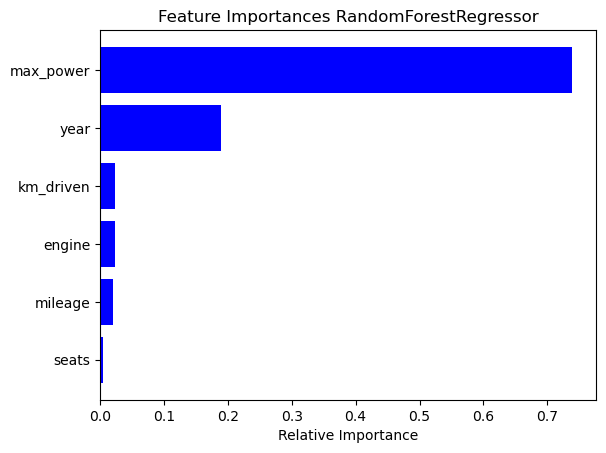

In [21]:
import matplotlib.pyplot as plt   # для работы с графиками
features = X_train.columns
importances = model_rf.feature_importances_
indices = np.argsort(importances)

plt.title('Feature Importances RandomForestRegressor')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()